In [2]:
from lib.metrics import *
from lib.model_loading import load_predictions

## Ensemble results


In [3]:
all_predictions = load_predictions("dropout", predictions_folder="predictions/results3_homo")
ensemble_predictions, true_values = all_predictions

mean_of_means, combined_log_variances = compute_combined_parameters(
    ensemble_predictions
)

print(calculate_all_metrics(ensemble_predictions, true_values))
# calibration_plot(mean_of_means, true_values)

{'combined_nll': tensor(949.1095), 'picp': 0.06261874002583782, 'correlations_uncertainty': {'pearson_corr': 0.0019242788243043407, 'pearson_p_value': 0.8253116843839011, 'spearman_corr': -0.0010632266835384808, 'spearman_p_value': 0.9029354209221622}}


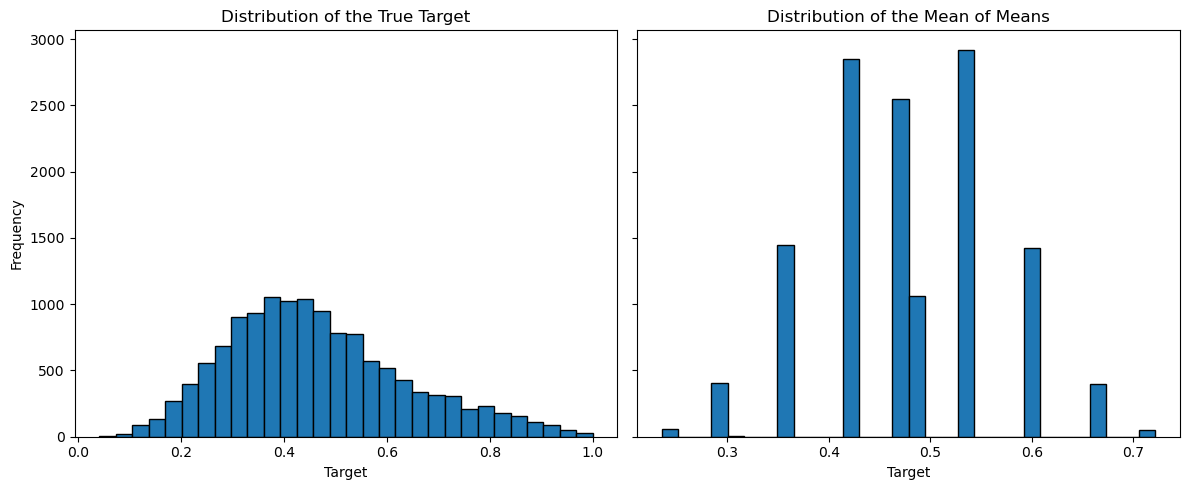

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plotting the distribution of the true target
axes[0].hist(true_values.numpy(), bins=30, edgecolor='black')
axes[0].set_title('Distribution of the True Target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Frequency')

# Plotting the distribution of the mean of means
axes[1].hist(mean_of_means.numpy(), bins=30, edgecolor='black')
axes[1].set_title('Distribution of the Mean of Means')
axes[1].set_xlabel('Target')

# Adjust layout
plt.tight_layout()
plt.show()


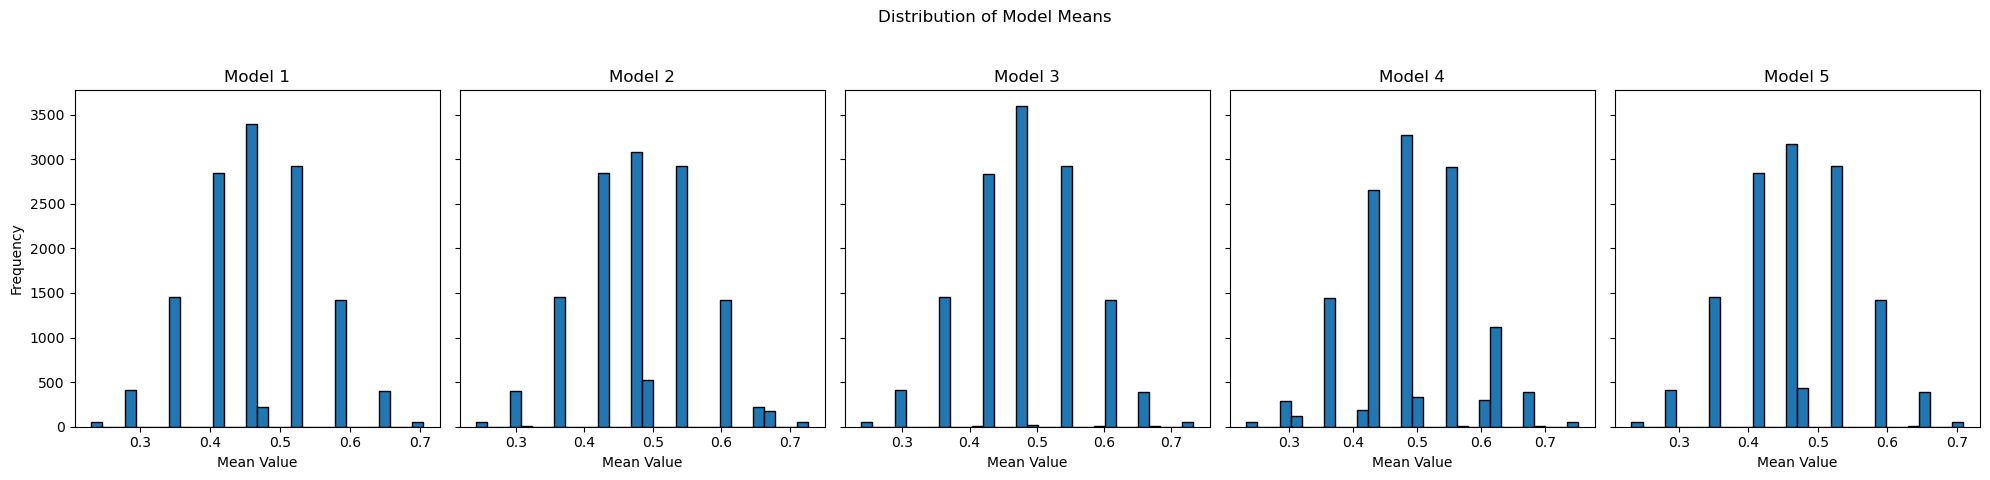

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, model_predictions in enumerate(ensemble_predictions):
    means = model_predictions[0]
    axes[i].hist(means, bins=30, edgecolor='black')
    axes[i].set_title(f'Model {i+1}')
    axes[i].set_xlabel('Mean Value')
    if i == 0:
        axes[i].set_ylabel('Frequency')

fig.suptitle('Distribution of Model Means')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


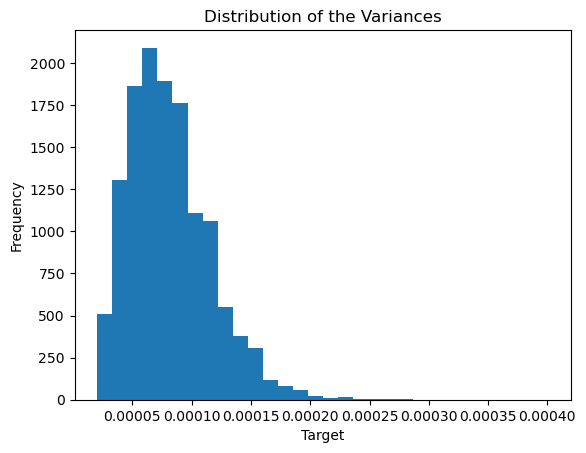

In [10]:
import matplotlib.pyplot as plt

plt.hist(np.exp(combined_log_variances).numpy(), bins=30)

plt.title('Distribution of the Variances')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

In [18]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

# for i, model_predictions in enumerate(ensemble_predictions):
#     variances = np.exp(model_predictions[1])
#     axes[i].hist(variances, bins=30, edgecolor='black')
#     axes[i].set_title(f'Model {i+1}')
#     axes[i].set_xlabel('Variance Value')
#     if i == 0:
#         axes[i].set_ylabel('Frequency')

# fig.suptitle('Distribution of Model Means')
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()


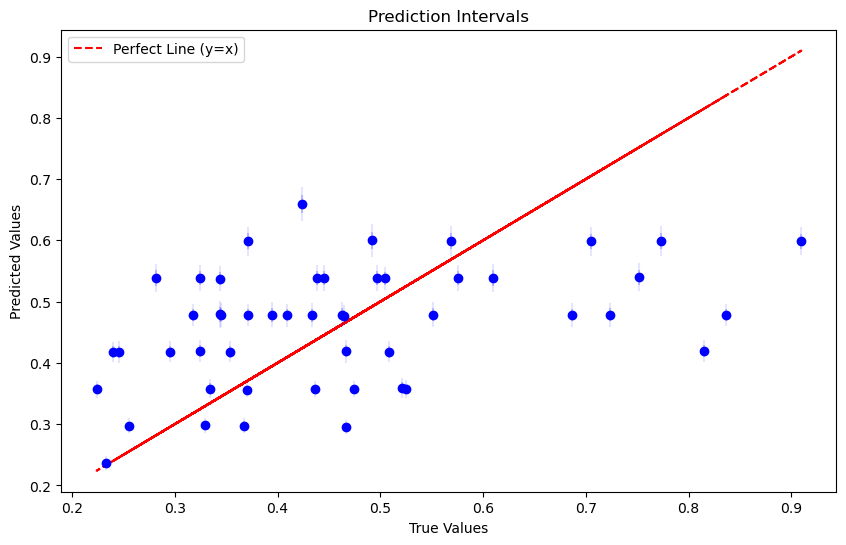

In [9]:
variances = torch.exp(combined_log_variances)

visualize_intervals(true_values.numpy(), mean_of_means.numpy(), variances.numpy(), num_points=50)